# Lesson 5.1 — When the Ellipsoid Collapses
**Module 6 · Unit 5 · Lesson 17**

Geometry first: as a planar 2R arm straightens, the manipulability ellipse's short axis shrinks to zero — a **lost direction** — while the long axis (available) barely changes. Companion to the *Ellipsoid Collapse* demo.

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
def reach(P,T,q):
    M=forward_chain(P,T,q)[-1]; return float(np.hypot(M[0,3],M[1,3]))
P2=[(0,0,1.0,0),(0,0,1.0,0)]; T2=["R","R"]            # planar 2R, L1=L2=1


## Sweep toward straight: the short axis (σ_min) collapses, area → 0

In [2]:
checks=[]
import matplotlib.pyplot as plt
t2s=np.array([1.2,0.8,0.4,0.2,0.1,0.05])
rows=[]
for t2 in t2s:
    s=np.linalg.svd(Jv_planar(P2,T2,np.array([0.4,t2])),compute_uv=False)
    rows.append((t2,s[0],s[1],s[0]*s[1]))
    print(f"theta2={t2:5.2f}  sigma_max={s[0]:.3f}  sigma_min={s[1]:.3f}  area w={s[0]*s[1]:.4f}")
checks.append(rows[-1][2]<0.05 and rows[-1][3]<0.06)

theta2= 1.20  sigma_max=1.864  sigma_min=0.500  area w=0.9320
theta2= 0.80  sigma_max=2.067  sigma_min=0.347  area w=0.7174
theta2= 0.40  sigma_max=2.193  sigma_min=0.178  area w=0.3894
theta2= 0.20  sigma_max=2.225  sigma_min=0.089  area w=0.1987
theta2= 0.10  sigma_max=2.233  sigma_min=0.045  area w=0.0998
theta2= 0.05  sigma_max=2.235  sigma_min=0.022  area w=0.0500


## Lost vs remaining directions at a near-singular pose

remaining (available) direction u_max: [-0.417  0.909]   length sigma_max= 2.235
lost direction u_min: [0.909 0.417]   length sigma_min= 0.0224


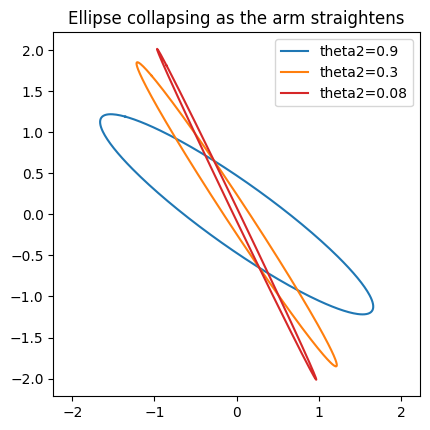

In [3]:
J=Jv_planar(P2,T2,np.array([0.4,0.05])); U,S,Vt=np.linalg.svd(J)
print("remaining (available) direction u_max:",np.round(U[:,0],3),"  length sigma_max=",round(S[0],3))
print("lost direction u_min:",np.round(U[:,1],3),"  length sigma_min=",round(S[1],4))
checks.append(S[0]>1.5 and S[1]<0.05)   # one axis healthy, one collapsed
# the lost direction is ~ radial (along the arm); remaining ~ perpendicular
plt.figure(figsize=(4.4,4.4))
ang=np.linspace(0,2*np.pi,300); circ=np.vstack([np.cos(ang),np.sin(ang)])
for t2,col in [(0.9,'#1f77b4'),(0.3,'#ff7f0e'),(0.08,'#d62728')]:
    e=Jv_planar(P2,T2,np.array([0.4,t2]))@circ; plt.plot(e[0],e[1],color=col,label=f'theta2={t2}')
plt.axis('equal'); plt.legend(); plt.title('Ellipse collapsing as the arm straightens'); plt.tight_layout(); plt.show()

In [4]:
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

All checks passed.
